**Packages**

In [75]:
import joblib
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Bidirectional
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

**Helper Functions**

In [53]:
def add_downtrend_indicator(df, price_col="Gold_Price"):
    """
        Helps in generating helpful indicators for trends of the Gold_Price
    """
    df = df.sort_index().copy()

    day_counts = []
    cum_drops = []

    prices = df[price_col].values
    n = len(prices)

    for i in range(n):
        day_count = 0
        start_price = prices[i]

        j = i - 1
        while j >= 0 and prices[j] > prices[j + 1]:
            day_count += 1
            j -= 1

        if day_count > 0:
            first_price = prices[i - day_count]
            cum_drop = (first_price - start_price) / first_price
        else:
            cum_drop = 0.0

        day_counts.append(day_count)
        cum_drops.append(cum_drop)

    df["day_count"] = day_counts
    df["cum_drop"] = cum_drops
    df["indicator"] = df["day_count"] * df["cum_drop"]

    return df

In [67]:
class RegressionModel:
    def __init__(self, model, name):
        self.model = model
        self.name = name

def get_models() -> list:
    """"
        Returns list of 2 regression models, which is helpful in testing the hypotesis about generating plan for stacking models.
    """
    xgb_model = XGBRegressor(
    n_estimators=100,       
    learning_rate=0.1,      
    max_depth=6,            
    subsample=0.8,          
    colsample_bytree=0.8,   
    random_state=42
    )

    rf_model = RandomForestRegressor(
    n_estimators=100,       
    max_depth=None,         
    min_samples_split=2,    
    min_samples_leaf=1,     
    max_features='sqrt',    
    random_state=42
    )

    return [
        RegressionModel(rf_model, "Random Forest Regressor"), 
        RegressionModel(xgb_model, "XGBRegressor Model")]
    

In [69]:
def calculate_metrics(y_test, y_pred) -> None:
    """ 
        Function to evaluate the model that returns pandas.Dataframe object.
    """
    mse = mean_squared_error(y_pred, y_test)
    mae = mean_absolute_error(y_pred, y_test)
    r2 = r2_score(y_pred, y_test)

    res = pd.DataFrame({
        "MSE": [mse],
        "MAE": [mae],
        "R2": [r2]
    })

    print(res)

In [84]:
def plot_results(y_test, y_preds, model: str) -> None:
    """
    Plots the results of training a model.
    Handles both pandas Series and numpy arrays, and LSTM or tree models.
    """
    y_test_plot = y_test.values if hasattr(y_test, 'values') else y_test
    y_preds_plot = y_preds.values if hasattr(y_preds, 'values') else y_preds

    plt.figure(figsize=(10,5))
    plt.plot(y_test_plot, label='Actual', color='blue')
    plt.plot(y_preds_plot, label=f'{model} Predictions', color='red')
    plt.title(f"{model} predictions on gold prices")
    plt.legend()
    plt.show()


In [71]:
class LSTMModel:
    def __init__(self, model, name):
            self.model = model
            self.name = name

def get_lstm_models(input_shape) -> list[LSTMModel]:
    """
        Returns list of lstm models for training, reduces redundant code.
    """
    lstm_model = Sequential()
    lstm_model = Sequential()
    lstm_model.add(Dropout(0.2))
    lstm_model.add(Dense(64, activation='relu'))
    lstm_model.add(Dense(1))  
    lstm_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

    bilstm_model = Sequential()
    bilstm_model.add(Bidirectional(LSTM(128, return_sequences=False), input_shape=input_shape))
    bilstm_model.add(Dropout(0.2))
    bilstm_model.add(Dense(64, activation='relu'))
    bilstm_model.add(Dense(1))
    bilstm_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

    return[
        LSTMModel(lstm_model, 'LSTM Neural Network'),
        LSTMModel(bilstm_model, 'BiLSTM Neural Network')
    ]

**Reading datasets**

In [29]:
def read_dataset(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, parse_dates=['Date'])
    print(df.head())
    return df

In [30]:
df = read_dataset('datasets/gold_data.csv')

        Date  Gold_Price  Crude_Oil  Inflation  Interest_Rate  USD_EUR  \
0 2019-12-02  137.789993      67.31     258.63           1.55   1.1075   
1 2019-12-03  139.110001      67.31     258.63           1.55   1.1089   
2 2019-12-04  138.919998      67.31     258.63           1.55   1.1076   
3 2019-12-05  139.000000      67.31     258.63           1.55   1.1104   
4 2019-12-06  137.619995      67.31     258.63           1.55   1.1052   

   USD_JPY        SLV        ^GSPC  
0   109.09  15.800000  3113.870117  
1   108.53  16.049999  3093.199951  
2   108.87  15.760000  3112.760010  
3   108.69  15.850000  3117.429932  
4   108.66  15.480000  3145.909912  


In [31]:
news_df = read_dataset('../gdelt_gold_news_sentiments.csv')

        Date                                               text sentiment
0 2015-12-27  Here's a summary of gold-related news based on...  negative
1 2015-12-28  Several reports discuss gold smuggling attempt...  positive
2 2015-12-29  Several reports discuss gold smuggling attempt...  positive
3 2015-12-30  Here's a summary of gold market news from the ...  positive
4 2015-12-31  Here's a summary of gold market news from the ...  positive


**Preprocessing**

In [32]:
news_df = news_df.query("Date >= '2019-12-02'")

In [33]:
merged = pd.merge(df, news_df, on="Date", how="left")

In [34]:
merged.isnull().sum()

Date             0
Gold_Price       0
Crude_Oil        0
Inflation        0
Interest_Rate    0
USD_EUR          0
USD_JPY          0
SLV              0
^GSPC            0
text             2
sentiment        2
dtype: int64

In [35]:
merged = merged.dropna()

In [36]:
le = LabelEncoder()
merged['sentiment_enc'] = le.fit_transform(merged['sentiment'])
merged.head()

,Date,Gold_Price,Crude_Oil,Inflation,Interest_Rate,USD_EUR,USD_JPY,SLV,^GSPC,text,sentiment,sentiment_enc
0,2019-12-02,137.789993,67.31,258.63,1.55,1.1075,109.09,15.800000,3113.870117,"Gold prices are experiencing some volatility, ...",negative,0
1,2019-12-03,139.110001,67.31,258.63,1.55,1.1089,108.53,16.049999,3093.199951,"Gold prices are experiencing some volatility, ...",negative,0
2,2019-12-04,138.919998,67.31,258.63,1.55,1.1076,108.87,15.760000,3112.760010,Gold prices are influenced by US-China trade u...,negative,0
3,2019-12-05,139.000000,67.31,258.63,1.55,1.1104,108.69,15.850000,3117.429932,Gold prices are influenced by US-China trade u...,negative,0
4,2019-12-06,137.619995,67.31,258.63,1.55,1.1052,108.66,15.480000,3145.909912,Wildsky Resources Inc. announced a purchase an...,positive,2


In [38]:
merged["up_down_flag"] = merged["Gold_Price"].diff().apply(lambda x: 1 if x > 0 else 0)
merged.head()

,Date,Gold_Price,Crude_Oil,Inflation,Interest_Rate,USD_EUR,USD_JPY,SLV,^GSPC,text,sentiment,sentiment_enc,up_down_flag
0,2019-12-02,137.789993,67.31,258.63,1.55,1.1075,109.09,15.800000,3113.870117,"Gold prices are experiencing some volatility, ...",negative,0,0
1,2019-12-03,139.110001,67.31,258.63,1.55,1.1089,108.53,16.049999,3093.199951,"Gold prices are experiencing some volatility, ...",negative,0,1
2,2019-12-04,138.919998,67.31,258.63,1.55,1.1076,108.87,15.760000,3112.760010,Gold prices are influenced by US-China trade u...,negative,0,0
3,2019-12-05,139.000000,67.31,258.63,1.55,1.1104,108.69,15.850000,3117.429932,Gold prices are influenced by US-China trade u...,negative,0,1
4,2019-12-06,137.619995,67.31,258.63,1.55,1.1052,108.66,15.480000,3145.909912,Wildsky Resources Inc. announced a purchase an...,positive,2,0


In [40]:
merged.columns

Index(['Date', 'Gold_Price', 'Crude_Oil', 'Inflation', 'Interest_Rate',
       'USD_EUR', 'USD_JPY', 'SLV', '^GSPC', 'text', 'sentiment',
       'sentiment_enc', 'up_down_flag'],
      dtype='object')

In [41]:
merged = merged.drop(columns=['text', 'sentiment'])
merged.head()

,Date,Gold_Price,Crude_Oil,Inflation,Interest_Rate,USD_EUR,USD_JPY,SLV,^GSPC,sentiment_enc,up_down_flag
0,2019-12-02,137.789993,67.31,258.63,1.55,1.1075,109.09,15.800000,3113.870117,0,0
1,2019-12-03,139.110001,67.31,258.63,1.55,1.1089,108.53,16.049999,3093.199951,0,1
2,2019-12-04,138.919998,67.31,258.63,1.55,1.1076,108.87,15.760000,3112.760010,0,0
3,2019-12-05,139.000000,67.31,258.63,1.55,1.1104,108.69,15.850000,3117.429932,0,1
4,2019-12-06,137.619995,67.31,258.63,1.55,1.1052,108.66,15.480000,3145.909912,2,0


In [44]:
df = add_downtrend_indicator(merged)

In [45]:
df.head()

,Date,Gold_Price,Crude_Oil,Inflation,Interest_Rate,USD_EUR,USD_JPY,SLV,^GSPC,sentiment_enc,up_down_flag,day_count,cum_drop,indicator
0,2019-12-02,137.789993,67.31,258.63,1.55,1.1075,109.09,15.800000,3113.870117,0,0,0,0.000000,0.000000
1,2019-12-03,139.110001,67.31,258.63,1.55,1.1089,108.53,16.049999,3093.199951,0,1,0,0.000000,0.000000
2,2019-12-04,138.919998,67.31,258.63,1.55,1.1076,108.87,15.760000,3112.760010,0,0,1,0.001366,0.001366
3,2019-12-05,139.000000,67.31,258.63,1.55,1.1104,108.69,15.850000,3117.429932,0,1,0,0.000000,0.000000
4,2019-12-06,137.619995,67.31,258.63,1.55,1.1052,108.66,15.480000,3145.909912,2,0,1,0.009928,0.009928


In [46]:
df.columns

Index(['Date', 'Gold_Price', 'Crude_Oil', 'Inflation', 'Interest_Rate',
       'USD_EUR', 'USD_JPY', 'SLV', '^GSPC', 'sentiment_enc', 'up_down_flag',
       'day_count', 'cum_drop', 'indicator'],
      dtype='object')

In [49]:
features = [col for col in df.columns if col not in ['Date', 'Gold_Price','up_down_flag',
       'day_count', 'cum_drop', 'indicator']]
target = 'Gold_Price'

feat_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

df[features] = feat_scaler.fit_transform(df[features])
df[target] = target_scaler.fit_transform(df[[target]])

df.head()

,Date,Gold_Price,Crude_Oil,Inflation,Interest_Rate,USD_EUR,USD_JPY,SLV,^GSPC,sentiment_enc,up_down_flag,day_count,cum_drop,indicator
0,2019-12-02,0.001751,0.468993,0.04576,0.284091,0.544606,0.110961,0.223575,0.227485,0.0,0,0,0.000000,0.000000
1,2019-12-03,0.012758,0.468993,0.04576,0.284091,0.549832,0.101503,0.235753,0.222120,0.0,1,0,0.000000,0.000000
2,2019-12-04,0.011174,0.468993,0.04576,0.284091,0.544979,0.107245,0.221627,0.227197,0.0,0,1,0.001366,0.001366
3,2019-12-05,0.011841,0.468993,0.04576,0.284091,0.555431,0.104205,0.226011,0.228409,0.0,1,0,0.000000,0.000000
4,2019-12-06,0.000333,0.468993,0.04576,0.284091,0.536021,0.103699,0.207988,0.235801,1.0,0,1,0.009928,0.009928


In [60]:
path = 'datasets/indicators-mega-gold-dataset.csv'
df.to_csv(path, index=False)

In [51]:
path = 'scalers/new-scalers/feat-scaler.pkl'
joblib.dump(feat_scaler, path)

path = 'scalers/new-scalers/target-scaler.pkl'
joblib.dump(target_scaler, path)


['scalers/new-scalers/target-scaler.pkl']

**Training**

***Option 1: Train each model directly on the full dataset***

In [58]:
features = [col for col in df.columns if col not in ['Date', 'Gold_Price']]
target = 'Gold_Price'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

        MSE       MAE          R2
0  0.117828  0.297551 -209.349674


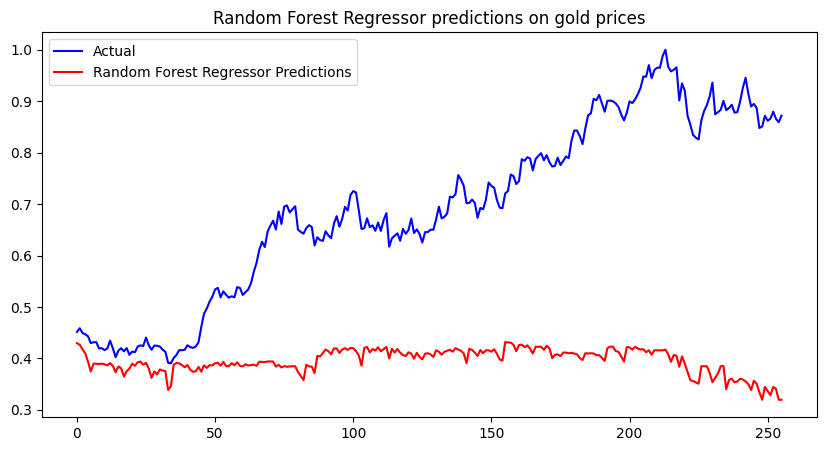




        MSE       MAE         R2
0  0.097182  0.270038 -138.28106


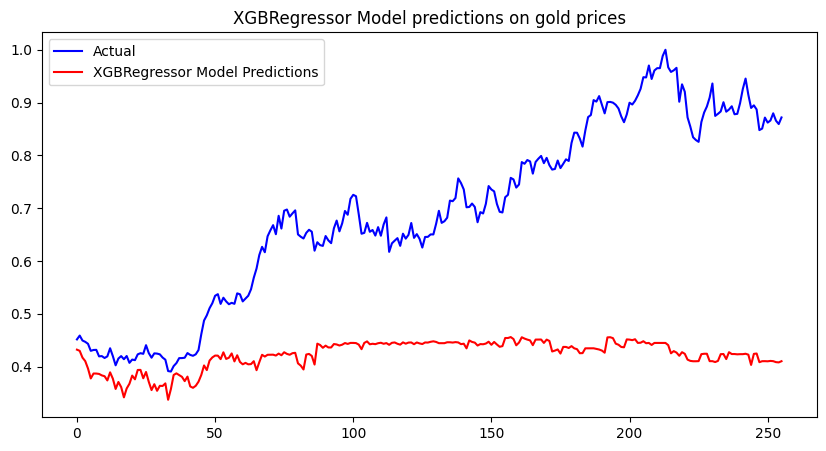

In [70]:
for model_obj in get_models():
    model = model_obj.model
    model.fit(X_train, y_train)
    y_preds = model.predict(X_test)
    calculate_metrics(y_test, y_preds)
    plot_results(y_test, y_preds, model_obj.name)
    print("\n\n")

**Trainig with LSTM and BiLSTM**

In [73]:
X_train = df[features].values
y_train = df[target].values
X_test = df[features].values
y_test = df[target].values


X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

In [76]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

Epoch 1/100


c:\Users\User\dev\training_model\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


36/36 - 1s - 27ms/step - loss: 0.0403 - val_loss: 0.2170
Epoch 2/100
36/36 - 0s - 4ms/step - loss: 0.0228 - val_loss: 0.2550
Epoch 3/100
36/36 - 0s - 4ms/step - loss: 0.0199 - val_loss: 0.2628
Epoch 4/100
36/36 - 0s - 5ms/step - loss: 0.0194 - val_loss: 0.2791
Epoch 5/100
36/36 - 0s - 4ms/step - loss: 0.0188 - val_loss: 0.3152
Epoch 6/100
36/36 - 0s - 4ms/step - loss: 0.0182 - val_loss: 0.3020
Epoch 7/100
36/36 - 0s - 5ms/step - loss: 0.0184 - val_loss: 0.2874
Epoch 8/100
36/36 - 0s - 5ms/step - loss: 0.0181 - val_loss: 0.2733
Epoch 9/100
36/36 - 0s - 4ms/step - loss: 0.0180 - val_loss: 0.2650
Epoch 10/100
36/36 - 0s - 5ms/step - loss: 0.0178 - val_loss: 0.2615
Epoch 11/100
36/36 - 0s - 5ms/step - loss: 0.0179 - val_loss: 0.3052
Epoch 1/100
36/36 - 3s - 92ms/step - loss: 0.0197 - val_loss: 0.1176
Epoch 2/100
36/36 - 0s - 6ms/step - loss: 0.0074 - val_loss: 0.1196
Epoch 3/100
36/36 - 0s - 6ms/step - loss: 0.0060 - val_loss: 0.0856
Epoch 4/100
36/36 - 0s - 6ms/step - loss: 0.0049 - val_l

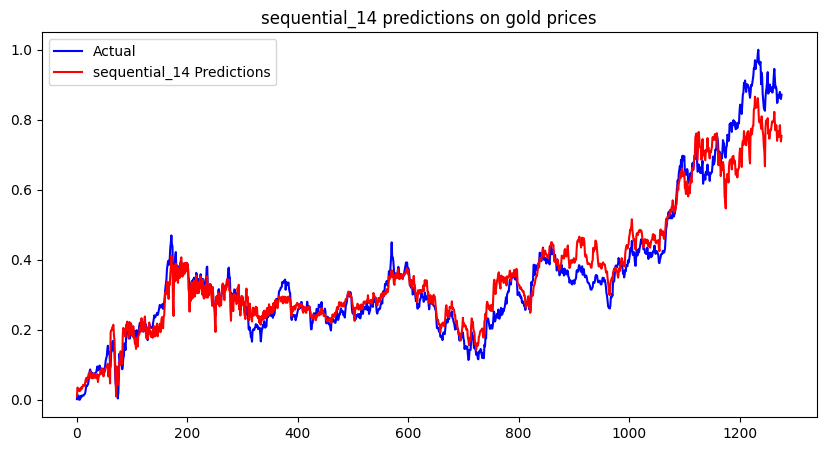

In [85]:
for nn in get_lstm_models((X_train.shape[1], X_train.shape[2])):
    model = nn.model
    history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=2
)

y_pred = model.predict(X_test)
calculate_metrics(y_test, y_pred)
plot_results(y_test, y_pred, model.name)


In [86]:
joblib.dump(model, 'models/new-models/new_bilstm_model.pkl')

['models/new-models/new_bilstm_model.pkl']